#LSN Exercises 10
## parallelizing the genethic algorithm


Gabriele Borroni (14768A)

---
## Parallel computing

This exercise focuses on the same problem as the previous one, but the algorithm now has to find the **shortest path visiting all the 110 Italian provincial capitals**.

As said before, the complexity of the TSP problem grows rapidly with the number of cities involved. This means that the code used in exercise 9 is expected to take a long time in performing the search of the best path when the number of cities is almost tripled.

To make the run faster, the code has been **parallelized** using the MPI library.
The code's structure is the same as before, the difference is in the main:

- Each core ("continent") performs an **independent** GA search
- Every Nmigr generations, each continent picks up a random partner and exchanges the best Nmigrants indivuals with it

this process is repeated for 20 migrations. At the end, the master node gathers all the best paths found from the nodes and selects the best among them to be printed on the output file. 

In the GA class, minor changes have been made from the previous exercise, mainly because of the fact that MPI interface is complex to use to send custom class-members in messages, so it's better to work with int/double in each data sent or received. During migrations, the nodes exhcange integer arrays, corresponding to the best individual, and then the method GA::Replace(), replaces the worst chromosome's genes with the ones in the received integer-array, instead of creating a new chromosome instance.

Same plots of those in exercise 9 show the results for 8 nodes. Best length found was 65.9026. 




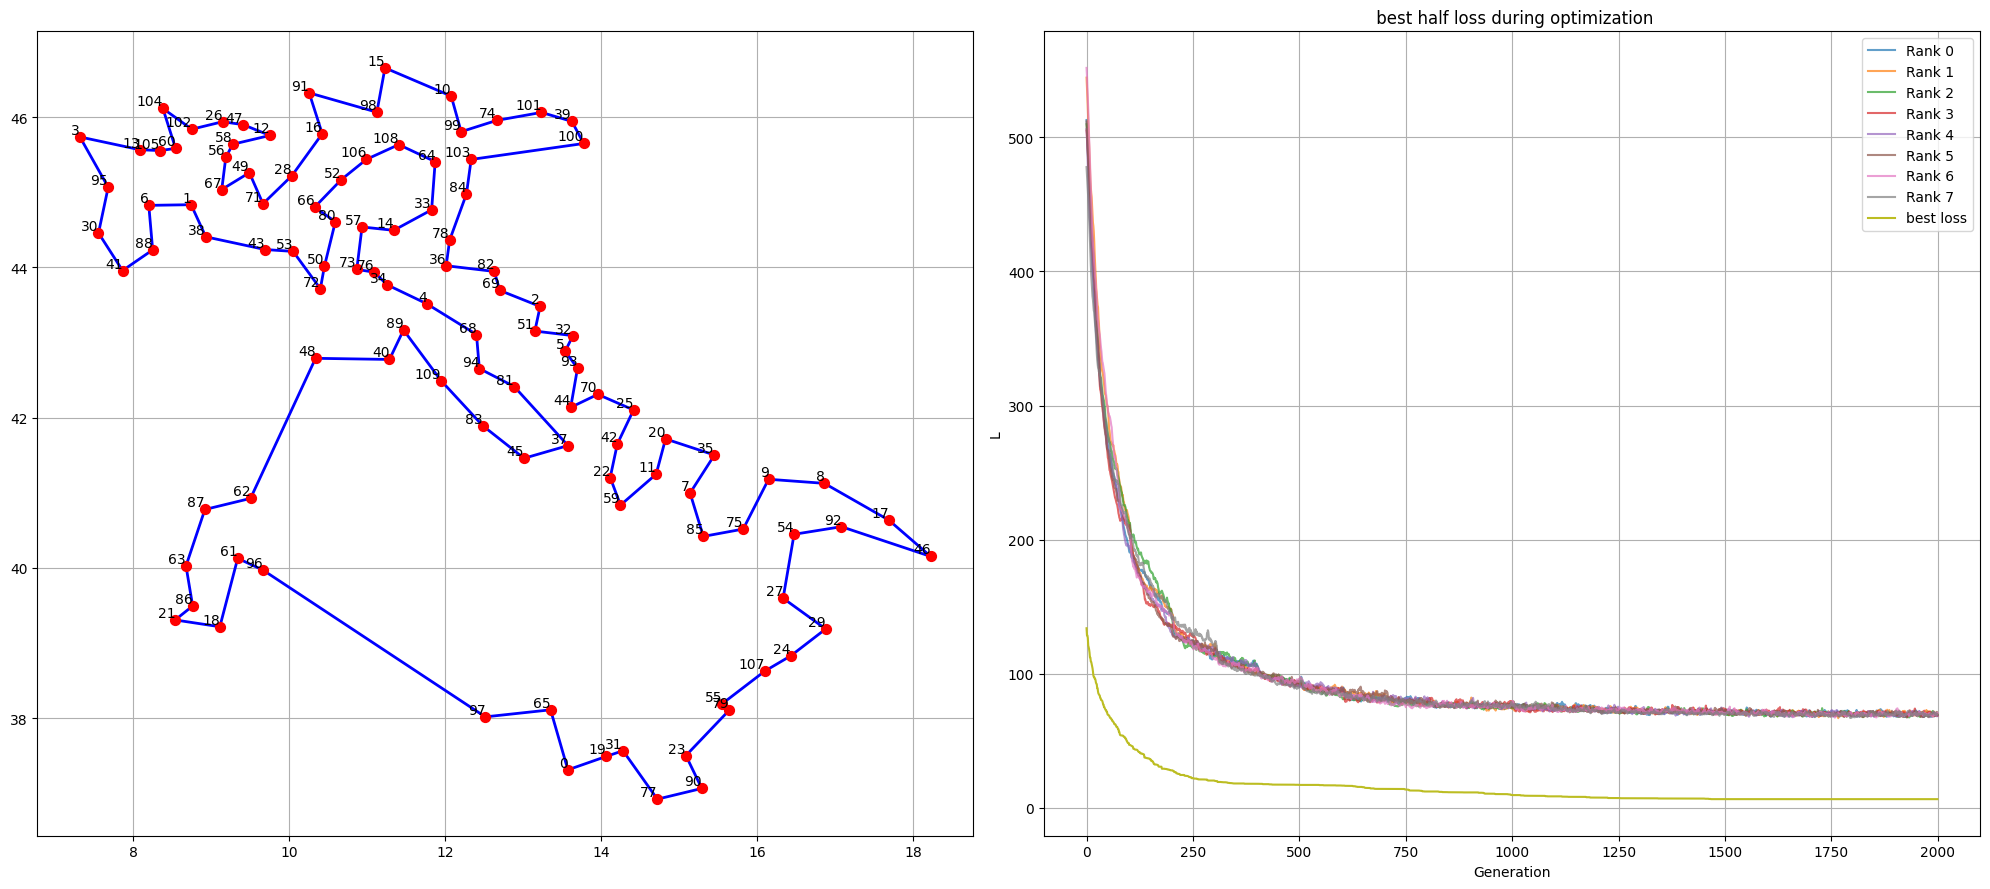

In [22]:
import matplotlib.pyplot as plt
import numpy as np

#load cities distribution
data = np.loadtxt("INPUT/cap_prov_ita.dat")
x_c = data [: , 0]
y_c = data [: , 1]
labels_c=np.arange(len(x_c))
#load best path
best_path = np.loadtxt("OUTPUT/best_path.dat", dtype=int)
x_path = x_c[best_path]
y_path = y_c[best_path]
#add return home
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])

def plot_losses(ax, base_name):
    generations = range(2000)
    for rank in range(8):
        data = np.loadtxt(f"OUTPUT/{base_name}loss{rank}.dat")
        values = data[:, 1]
        plt.plot(generations, values, label=f"Rank {rank}", alpha=0.7)
    best=np.loadtxt("OUTPUT/best_loss.dat")
    valbest=best[:,1]
    ax.plot(generations, valbest, label="best loss")
    plt.title(" best half loss during optimization")
    plt.xlabel("Generation")
    plt.ylabel("L")
    plt.grid()
    plt.legend()




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

plot_losses(ax2, "besthalf")
ax2.plot()

#plot best path
ax1.plot(x_path, y_path, 'b-o', linewidth=2, markersize=6, label='Best path')
ax1.scatter(x_c, y_c, color='red', s=50, zorder=3)
for i, label in enumerate(labels_c):
    ax1.text(x_c[i], y_c[i], str(label), fontsize=10, ha='right', va='bottom')
ax1.grid(True)


plt.tight_layout()
plt.show()
